In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [14]:
pd.set_option('display.max_columns',500)



#lectura de la base de datos
df=pd.read_excel("Table S1.xlsx")
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,Latitude,Longitude,Depth (km),Vp/Vs
3,-21.741,-69.156,5,"1,7683988809585571"
4,-21.741,-69.136654,5,"1,7683988809585571"


In [15]:

df = df.rename(columns = {"Unnamed: 0":"x","Unnamed: 1":"y","Unnamed: 2":"z","Unnamed: 3":"f"})
df.head()

,x,y,z,f
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,Latitude,Longitude,Depth (km),Vp/Vs
3,-21.741,-69.156,5,"1,7683988809585571"
4,-21.741,-69.136654,5,"1,7683988809585571"


In [16]:
df = df.drop(df.index[:3])
df.head()

,x,y,z,f
3,-21.741,-69.156,5,"1,7683988809585571"
4,-21.741,-69.136654,5,"1,7683988809585571"
5,-21.741,-69.117308,5,"1,7683988809585571"
6,-21.741,-69.097962,5,"1,7683988809585571"
7,-21.741,-69.078616,5,"1,7683988809585571"


In [23]:
df["f"].describe()

count                 183768
unique                123453
top       1,7684009075164795
freq                    3262
Name: f, dtype: object

In [24]:
df['f'] = df['f'].str.replace(',','.').astype(float)

In [25]:
def slice_yz(df, x0, tol=0.2):
    df_slice = df[np.abs(df['x'] - x0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['y'],
        df_slice['z'],
        c=df_slice['f']
    )
    plt.colorbar(sc, label='f')

    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(f'Corte YZ en x ≈ {x0}')
    plt.show()

In [26]:
def slice_xy(df, z0, tol=0.2):
    df_slice = df[np.abs(df['z'] - z0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['x'],
        df_slice['y'],
        c=df_slice['f']
    )
    plt.colorbar(sc, label='f')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Corte YZ en z ≈ {z0}')
    plt.show()

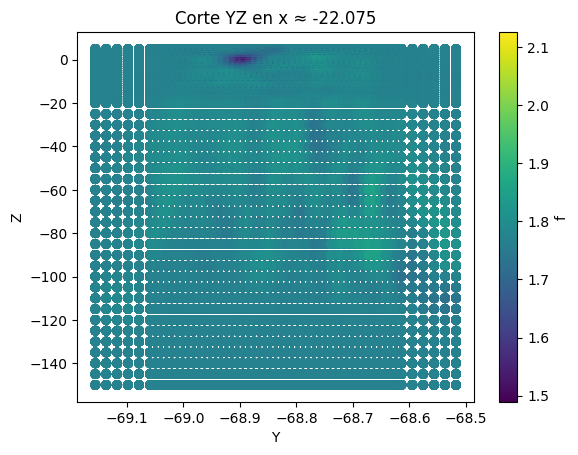

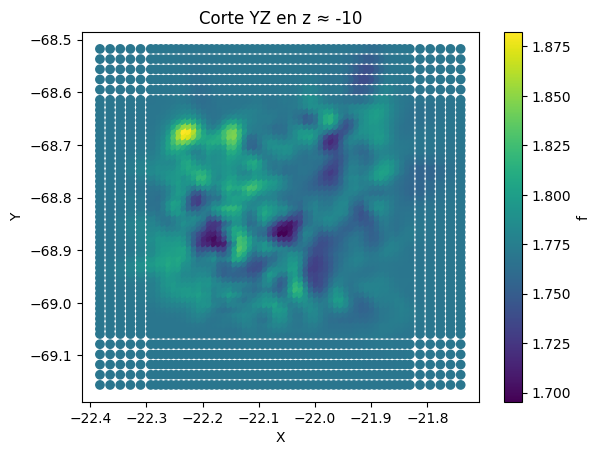

In [28]:
slice_yz(df, x0 = -22.075)
slice_xy(df, z0 = -10)

In [29]:
sizesx = df.groupby(['y','z']).size()
print(sizesx.describe())
sizesy = df.groupby(['x','z']).size()
print(sizesy.describe())
sizesz = df.groupby(['y','x']).size()
print(sizesz.describe())

count    2964.0
mean       62.0
std         0.0
min        62.0
25%        62.0
50%        62.0
75%        62.0
max        62.0
dtype: float64
count    3224.0
mean       57.0
std         0.0
min        57.0
25%        57.0
50%        57.0
75%        57.0
max        57.0
dtype: float64
count    3534.0
mean       52.0
std         0.0
min        52.0
25%        52.0
50%        52.0
75%        52.0
max        52.0
dtype: float64


In [31]:
def derivada_z(grupo):
    grupo = grupo.sort_values('z')
    z = grupo['z'].values
    f = grupo['f'].values
    
    df_dz = np.gradient(f, z)
    grupo['df_dz'] = df_dz
    return grupo

def derivada_x(grupo):
    grupo = grupo.sort_values('x')
    x = grupo['x'].values
    f = grupo['f'].values
    
    df_dx = np.gradient(f, x)
    grupo['df_dx'] = df_dx
    return grupo

def derivada_y(grupo):
    grupo = grupo.sort_values('y')
    y = grupo['y'].values
    f = grupo['f'].values
    
    df_dy = np.gradient(f, y)
    grupo['df_dy'] = df_dy
    return grupo

In [32]:
grupo = df.groupby(['y','x'],group_keys = False).apply(derivada_z)
df["df_dz"] = grupo["df_dz"]
grupo = df.groupby(['y','z'],group_keys = False).apply(derivada_x)
df["df_dx"] = grupo["df_dx"]
grupo = df.groupby(['z','x'],group_keys = False).apply(derivada_y)
df["df_dy"] = grupo["df_dy"]

C:\Users\jqnra\AppData\Local\Temp\ipykernel_39984\534779186.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grupo = df.groupby(['y','x'],group_keys = False).apply(derivada_z)
C:\Users\jqnra\AppData\Local\Temp\ipykernel_39984\534779186.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grupo = df.groupby(['y','z'],group_keys = False).apply(derivada_x)
C:\Users\jqnra\AppData\Local\Temp\ipykernel_39984\534779186.py

In [34]:
df["norm_df"] = (df["df_dz"]**2+df["df_dy"]**2+df["df_dx"]**2)

In [36]:
df["norm_df"].describe()

count    183768.000000
mean          1.601479
std           6.136038
min           0.000000
25%           0.002222
50%           0.166534
75%           1.197963
max         371.060687
Name: norm_df, dtype: float64

In [38]:
df["exp_norm_df"] = np.exp(df["norm_df"])

In [43]:
def slice_yz_exp_norm_df(df, x0, tol=0.2):
    df_slice = df[np.abs(df['x'] - x0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['y'],
        df_slice['z'],
        c=df_slice['exp_norm_df']
    )
    plt.colorbar(sc, label='exp_norm_df')

    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(f'Corte YZ en x ≈ {x0}')
    plt.show()

In [ ]:
def slice_xy_exp_norm_df(df, z0, tol=0.2):
    df_slice = df[np.abs(df['z'] - z0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['x'],
        df_slice['y'],
        c=df_slice['exp_norm_df']
    )
    plt.colorbar(sc, label='exp_norm_df')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Corte YZ en z ≈ {z0}')
    plt.show()

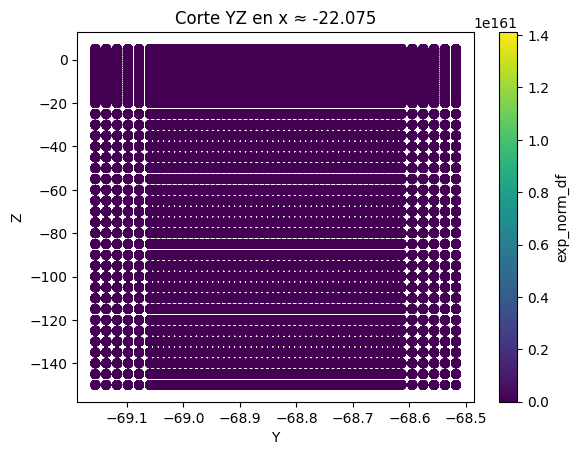

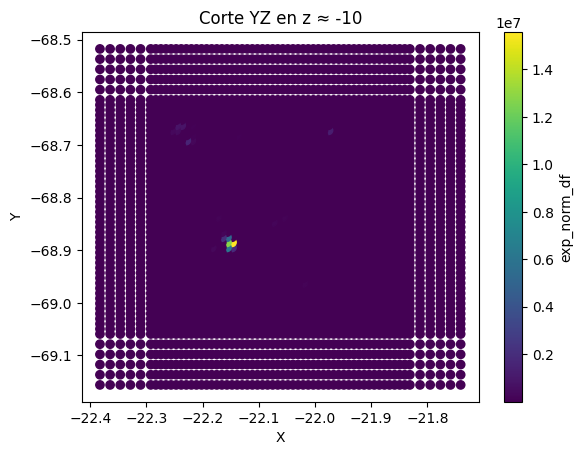

In [45]:
slice_yz_exp_norm_df(df, x0 = -22.075)
slice_xy_exp_norm_df(df, z0 = -10)

In [46]:
def slice_xy_norm_df(df, z0, tol=0.2):
    df_slice = df[np.abs(df['z'] - z0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['x'],
        df_slice['y'],
        c=df_slice['norm_df']
    )
    plt.colorbar(sc, label='norm_df')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Corte YZ en z ≈ {z0}')
    plt.show()

def slice_yz_norm_df(df, x0, tol=0.2):
    df_slice = df[np.abs(df['x'] - x0) < tol]

    plt.figure()
    sc = plt.scatter(
        df_slice['y'],
        df_slice['z'],
        c=df_slice['norm_df']
    )
    plt.colorbar(sc, label='norm_df')

    plt.xlabel('Y')
    plt.ylabel('Z')
    plt.title(f'Corte YZ en x ≈ {x0}')
    plt.show()

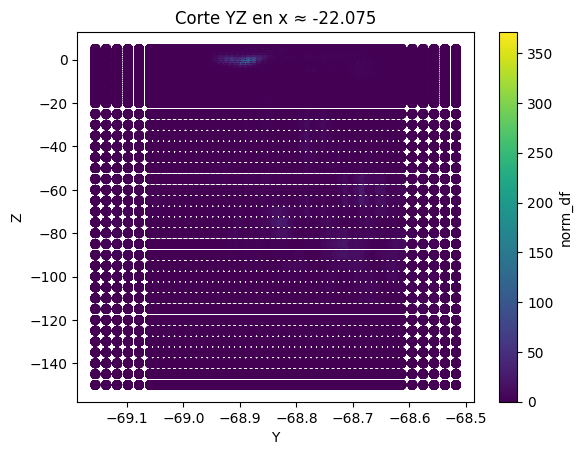

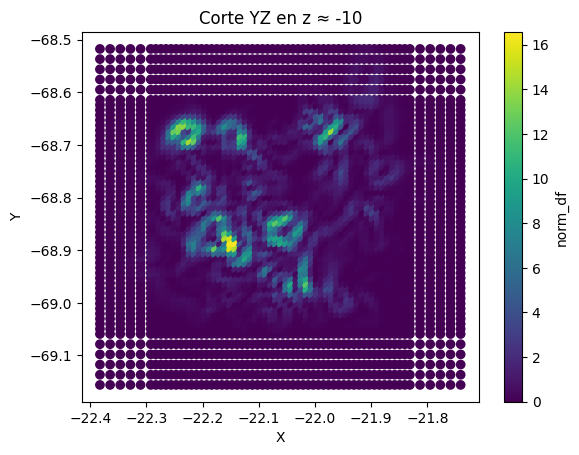

In [47]:
slice_yz_norm_df(df, x0 = -22.075)
slice_xy_norm_df(df, z0 = -10)

La idea es hacer una interpolación de tipo Kriging.
Probar inverso de la distancia, 
Vecino más cercano.

Tener la primera aproximación (tal vez el pc que tenemos no corra así que hay que buscar alternativas)


Tratar de en estos mapas en planta tratar de super poner las dos bases de datos, tomografía por una parte y geoquímica.